<a href="https://colab.research.google.com/github/weagan/In-Context-Learning/blob/main/lora_vs__ICL_using_nearest_neighbor_over_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets peft accelerate matplotlib scikit-learn

In [ ]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "distilbert-base-uncased"

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Device:", device)

Device: cuda


In [ ]:
def generate_example():
    names = ["Alice", "Bob", "Charlie", "Diana"]
    cities = ["Paris", "Rome", "Berlin", "Madrid"]
    foods = ["pizza", "sushi", "tacos", "pasta"]

    person = random.choice(names)
    city = random.choice(cities)
    food = random.choice(foods)

    context = f"{person} lives in {city}. People in {city} love {food}."
    question = f"What food does {person} like?"

    return {
        "text": context + " " + question,
        "label": food
    }

data = [generate_example() for _ in range(300)]

labels = list(set([d["label"] for d in data]))
label2id = {l:i for i,l in enumerate(labels)}
id2label = {i:l for l,i in label2id.items()}

for d in data:
    d["label"] = label2id[d["label"]]

dataset = Dataset.from_list(data)
dataset = dataset.train_test_split(test_size=0.2)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print("Labels:", label2id)

Labels: {'tacos': 0, 'pizza': 1, 'sushi': 2, 'pasta': 3}


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

In [ ]:
print(f"The maximum context size for '{MODEL_NAME}' is: {tokenizer.model_max_length} tokens.")

The maximum context size for 'distilbert-base-uncased' is: 512 tokens.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels)
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin","v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

model = get_peft_model(model, lora_config)
model.to(device)

print(model.print_trainable_parameters())

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948
None


In [ ]:
def compute_metrics(eval_pred):
    logits, labels_ = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels_, preds)
    return {"accuracy": acc}

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.381091,1.396655,0.300000
2,1.354020,1.377484,0.283333
3,1.348097,1.363571,0.500000
4,1.299544,1.341111,0.550000
5,1.308869,1.332983,0.566667


TrainOutput(global_step=150, training_loss=1.346846841176351, metrics={'train_runtime': 13.5247, 'train_samples_per_second': 88.727, 'train_steps_per_second': 11.091, 'total_flos': 40424656896000.0, 'train_loss': 1.346846841176351, 'epoch': 5.0})

In [ ]:
lora_results = trainer.evaluate()
print("LoRA Accuracy:", lora_results["eval_accuracy"])

LoRA Accuracy: 0.5666666666666667


# Simulate ICL using nearest-neighbor over embeddings
from sklearn.metrics.pairwise import cosine_similarity

def get_embeddings(texts):
    with torch.no_grad():
        inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
        # Correctly access the base DistilBERT model for embeddings
        outputs = model.base_model.distilbert(**inputs)
        return outputs.last_hidden_state[:,0,:].cpu().numpy()

train_texts = [d["text"] for d in data[:200]]
train_labels = [label2id[d["label"]] if isinstance(d["label"], str) else d["label"] for d in data[:200]]

test_texts = [d["text"] for d in data[200:]]
test_labels = [label2id[d["label"]] if isinstance(d["label"], str) else d["label"] for d in data[200:]]

train_emb = get_embeddings(train_texts)
test_emb = get_embeddings(test_texts)

preds = []
for emb in test_emb:
    sims = cosine_similarity([emb], train_emb)[0]
    idx = np.argmax(sims)
    preds.append(train_labels[idx])

icl_acc = accuracy_score(test_labels, preds)
print("ICL (NN) Accuracy:", icl_acc)

### Recalculating ICL Accuracy with a Base Model (without LoRA)

To ensure a fair comparison, we'll now load a fresh instance of the model without any LoRA adapters and use its embeddings for the In-Context Learning (Nearest Neighbor) approach. This will show the performance of ICL using the original pre-trained DistilBERT representations.

In [ ]:
# Simulate ICL using nearest-neighbor over embeddings
from sklearn.metrics.pairwise import cosine_similarity

base_model_for_icl = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels)
)
base_model_for_icl.to(device)

def get_embeddings_base_model(texts):
    with torch.no_grad():
        inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
        outputs = base_model_for_icl.distilbert(**inputs)
        return outputs.last_hidden_state[:,0,:].cpu().numpy()


train_texts = [d["text"] for d in data[:200]]
train_labels = [label2id[d["label"]] if isinstance(d["label"], str) else d["label"] for d in data[:200]]

test_texts = [d["text"] for d in data[200:]]
test_labels = [label2id[d["label"]] if isinstance(d["label"], str) else d["label"] for d in data[200:]]

train_emb_base = get_embeddings_base_model(train_texts)
test_emb_base = get_embeddings_base_model(test_texts)

preds_base = []
for emb in test_emb_base:
    sims = cosine_similarity([emb], train_emb_base)[0]
    idx = np.argmax(sims)
    preds_base.append(train_labels[idx])

icl_acc_base = accuracy_score(test_labels, preds_base)
print("ICL (NN) Accuracy (Base Model):", icl_acc_base)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ICL (NN) Accuracy (Base Model): 0.99


In [ ]:
num_examples_for_icl_small = 4

train_texts_small = [d["text"] for d in data[:num_examples_for_icl_small]]
train_labels_small = [label2id[d["label"]] if isinstance(d["label"], str) else d["label"] for d in data[:num_examples_for_icl_small]]

test_texts_icl_small = [d["text"] for d in data[200:]]
test_labels_icl_small = [label2id[d["label"]] if isinstance(d["label"], str) else d["label"] for d in data[200:]]

train_emb_small = get_embeddings_base_model(train_texts_small)
test_emb_small = get_embeddings_base_model(test_texts_icl_small)

preds_small = []
for emb in test_emb_small:
    sims = cosine_similarity([emb], train_emb_small)[0]
    idx = np.argmax(sims)
    preds_small.append(train_labels_small[idx])

icl_acc_small = accuracy_score(test_labels_icl_small, preds_small)
print(f"ICL (NN) Accuracy (Base Model with {num_examples_for_icl_small} examples):", icl_acc_small)


ICL (NN) Accuracy (Base Model with 4 examples): 0.44


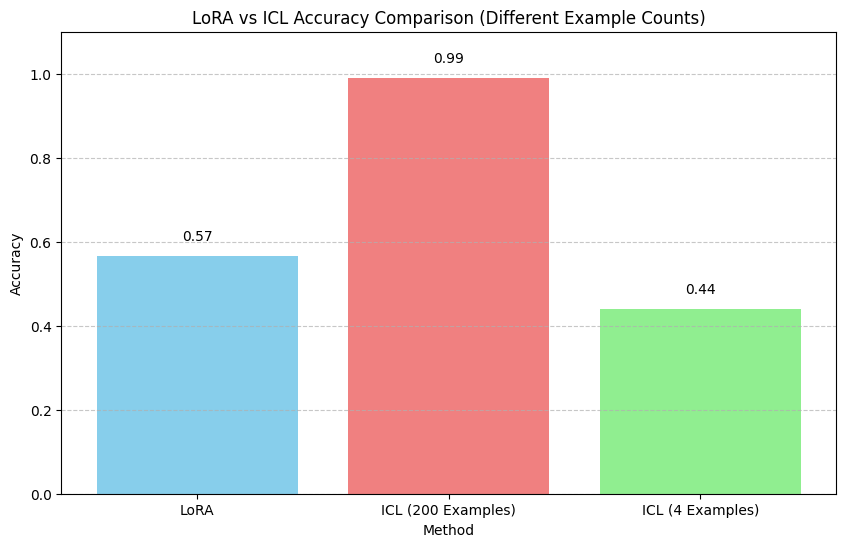

In [ ]:
labels_plot = ["LoRA", "ICL (200 Examples)", "ICL (4 Examples)"]
values = [lora_results["eval_accuracy"], icl_acc_base, icl_acc_small]

plt.figure(figsize=(10, 6))
plt.bar(labels_plot, values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title("LoRA vs ICL Accuracy Comparison (Different Example Counts)")
plt.ylabel("Accuracy")
plt.xlabel("Method")
plt.ylim(0, 1.1) # Set y-axis limit for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for i, value in enumerate(values):
    plt.text(i, value + 0.03, f'{value:.2f}', ha='center', va='bottom')

plt.show()


### Updated Comparison Plot

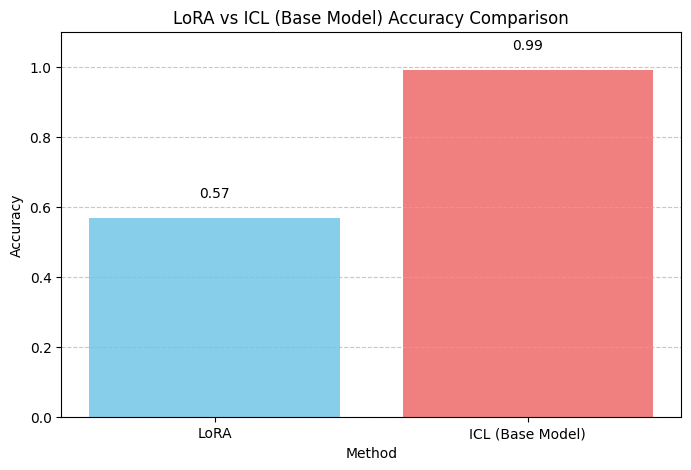

In [ ]:
labels_plot = ["LoRA", "ICL (Base Model)"]
values = [lora_results["eval_accuracy"], icl_acc_base]

plt.figure(figsize=(8, 5))
plt.bar(labels_plot, values, color=['skyblue', 'lightcoral'])
plt.title("LoRA vs ICL (Base Model) Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Method")
plt.ylim(0, 1.1) # Set y-axis limit for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of bars
for i, value in enumerate(values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

plt.show()